# Fisher’s Linear Discriminant (LDA) - Hands-on Notebook

Pattern Recognition, Week 6

## 1. Data Preparation

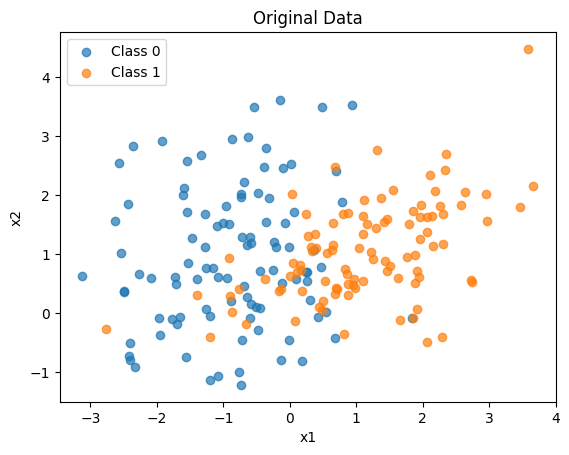

In [9]:
from sklearn.datasets import make_classification, load_iris
import numpy as np
import matplotlib.pyplot as plt

# Generate a 2-class dataset (2D for visualization)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           n_classes=2, random_state=42)

# Visualize
plt.scatter(X[y==0,0], X[y==0,1], label='Class 0', alpha=0.7)
plt.scatter(X[y==1,0], X[y==1,1], label='Class 1', alpha=0.7)
plt.title('Original Data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

In [10]:
X.shape

(200, 2)

In [11]:
X[y==0].T

array([[-0.11959689, -0.00745441, -1.25396925, -0.24392415, -1.9208928 ,
         0.48806269, -3.12190908,  0.46785542, -0.54235518, -2.41167954,
         0.09529002, -1.64994223, -1.70056309,  0.30162791, -0.6910389 ,
        -0.10191136, -1.09936351, -0.47995197, -2.54154743,  0.35734448,
        -1.54796112,  0.41873144, -0.72131493, -0.44891081, -1.70707082,
        -0.13866279,  0.54178214, -1.15134201, -1.00544154, -2.41201542,
        -0.38380103, -2.40818907, -1.76691875, -0.20876699, -1.5434072 ,
        -1.40349166, -2.49380858, -1.72457845,  0.17855096, -0.93877103,
        -1.52852845, -1.46545609, -0.3581415 , -0.60404357, -0.72886112,
        -1.19667757,  0.68583542,  0.25208052, -1.9695403 , -0.64061899,
        -0.72784069, -1.27509973, -1.08582248, -0.62154585, -2.63559457,
        -2.35888098, -0.68341504, -1.19799362, -1.07817905, -0.76699391,
        -0.35490992,  1.83871449, -0.96650639, -2.27093881, -1.59643538,
        -0.14989682,  0.25633049, -0.44758139, -0.5

## 2. Manual Fisher’s LDA (Binary Case)

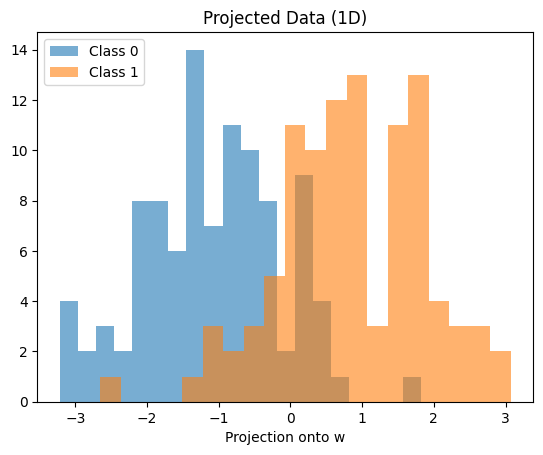

In [12]:
# Compute class means
# between class scatter =
mu0 = X[y==0].mean(axis=0)
mu1 = X[y==1].mean(axis=0)

# Compute within-class scatter(we want to minimize this)
# np.cov expect features as rows e.g. we have 2 rows from 2 coef
# each row have 200 columns : each sample
S0 = np.cov(X[y==0].T, bias=True)
S1 = np.cov(X[y==1].T, bias=True)
Sw = S0 + S1 # with in class

# Compute optimal projection vector w
w = np.linalg.inv(Sw).dot(mu1 - mu0) # this expression for lda

# Project data
z = X.dot(w)

# Plot histograms of projections
plt.hist(z[y==0], bins=20, alpha=0.6, label='Class 0')
plt.hist(z[y==1], bins=20, alpha=0.6, label='Class 1')
plt.title("Projected Data (1D)")
plt.xlabel("Projection onto w")
plt.legend()
plt.show()

## 3. Classification with Threshold

In [13]:
# Threshold at midpoint between projected means
z0 = z[y==0]
z1 = z[y==1]
thresh = (z0.mean() + z1.mean()) / 2
y_pred = (z > thresh).astype(int)

from sklearn.metrics import accuracy_score, confusion_matrix
print("Accuracy:", accuracy_score(y, y_pred))
print("Confusion matrix:\n", confusion_matrix(y, y_pred))

Accuracy: 0.84
Confusion matrix:
 [[83 17]
 [15 85]]


## 4. LDA using scikit-learn

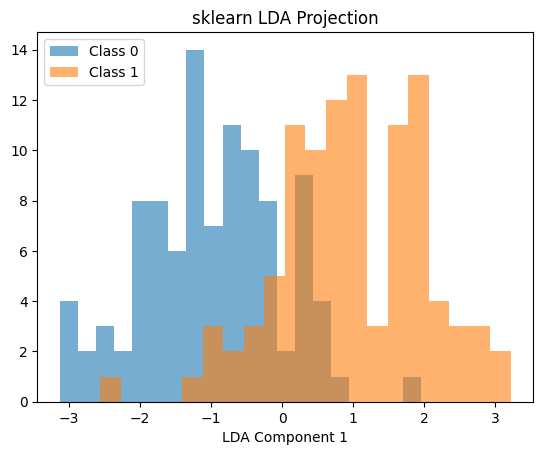

LDA accuracy: 0.84


In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

plt.hist(X_lda[y==0], bins=20, alpha=0.6, label='Class 0')
plt.hist(X_lda[y==1], bins=20, alpha=0.6, label='Class 1')
plt.title("sklearn LDA Projection")
plt.xlabel("LDA Component 1")
plt.legend()
plt.show()

print("LDA accuracy:", lda.score(X, y))

## 5. LDA on Multiclass Data (Iris)
We can use LDA to project to up to (n_classes - 1) dimensions.

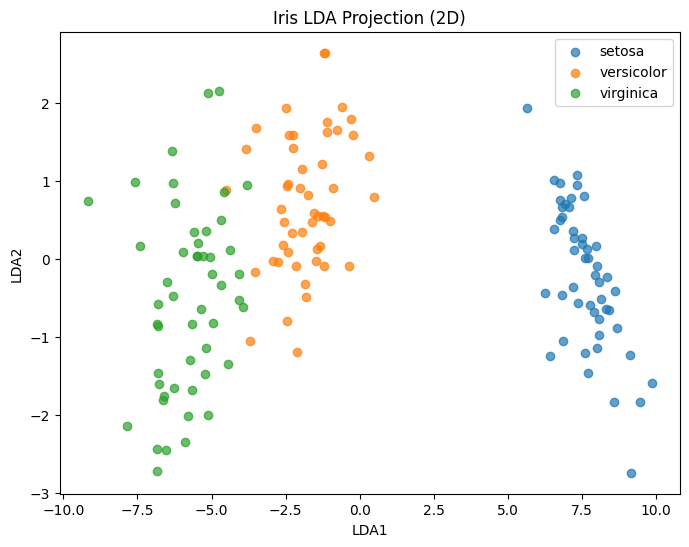

In [15]:
iris = load_iris()
X2, y2 = iris.data, iris.target
lda2 = LDA(n_components=2)
X2_lda = lda2.fit_transform(X2, y2)
plt.figure(figsize=(8,6))
for i, c in enumerate(iris.target_names):
    plt.scatter(X2_lda[y2==i,0], X2_lda[y2==i,1], label=c, alpha=0.7)
plt.title("Iris LDA Projection (2D)")
plt.xlabel("LDA1")
plt.ylabel("LDA2")
plt.legend()
plt.show()

## 6. Comparison: LDA vs PCA vs Logistic Regression
Try projecting data with PCA and compare.
(For the curious: add code to fit PCA and logistic regression and plot boundaries.)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2, test_size=0.3)
model2 = LogisticRegression()
model2.fit(X2_train,y2_train)
y2_pred = model2.predict(X2_test)
print(classification_report(y2_pred, y2_test))
for pred, true in zip(y2_pred, y2_test):
    correct = (pred==true)
    print((pred, true, correct))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.94      0.88      0.91        17
           2       0.89      0.94      0.91        17

    accuracy                           0.93        45
   macro avg       0.94      0.94      0.94        45
weighted avg       0.93      0.93      0.93        45

(np.int64(0), np.int64(0), np.True_)
(np.int64(2), np.int64(2), np.True_)
(np.int64(2), np.int64(2), np.True_)
(np.int64(2), np.int64(2), np.True_)
(np.int64(0), np.int64(0), np.True_)
(np.int64(1), np.int64(1), np.True_)
(np.int64(2), np.int64(2), np.True_)
(np.int64(1), np.int64(1), np.True_)
(np.int64(1), np.int64(1), np.True_)
(np.int64(2), np.int64(2), np.True_)
(np.int64(1), np.int64(1), np.True_)
(np.int64(1), np.int64(2), np.False_)
(np.int64(2), np.int64(1), np.False_)
(np.int64(1), np.int64(1), np.True_)
(np.int64(1), np.int64(1), np.True_)
(np.int64(0), np.int64(0), np.True_)
(np.int64(2), np.int64(2)